In [9]:
%pip install python-dotenv


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from dotenv import load_dotenv
load_dotenv()

True

In [11]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

In [12]:
from langchain.chat_models import init_chat_model


In [13]:
%pip install -qU langchain-tavily


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from langchain_tavily import TavilySearch


In [15]:
tavily_tool = TavilySearch(
    max_results=3,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    # include_images=False,
    # include_image_descriptions=False,
    # search_depth="basic",
    # time_range="day",
    # include_domains=None,
    # exclude_domains=None
)

In [17]:
gemini_llm = init_chat_model(model="gemini-2.0-flash-lite-001", model_provider="google_vertexai", project="buoyant-keel-461215-a8")

In [18]:
tool_node = ToolNode([tavily_tool])
gemini_llm_with_tools = gemini_llm.bind_tools([tavily_tool])

In [19]:
def call_model(state: MessagesState) -> MessagesState:
    state['messages'] = gemini_llm_with_tools.invoke(state['messages'])
    return state

In [20]:
tools_graph_builder = StateGraph(MessagesState)
tools_graph_builder.add_node("llm", call_model)
tools_graph_builder.add_node("tools", tool_node)
tools_graph_builder.add_edge("llm", "tools")
tools_graph_builder.set_entry_point("llm")
tools_graph_builder.set_finish_point("tools")
tools_graph = tools_graph_builder.compile()

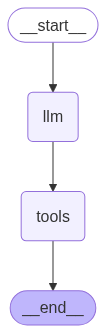

In [21]:
from IPython.display import Image, display
display(Image(tools_graph.get_graph().draw_mermaid_png()))

In [22]:
results = tools_graph.invoke({"messages": "What are latest updates from Google Gemini?"})


d:\GenAI_practice\Gen-AI\.venv\Lib\site-packages\google\auth\_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [23]:
results

{'messages': [HumanMessage(content='What are latest updates from Google Gemini?', additional_kwargs={}, response_metadata={}, id='2fc8d5bc-8678-491c-abb7-881318ac7d19'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "latest updates from Google Gemini", "topic": "news"}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 770, 'candidates_token_count': 12, 'total_token_count': 782, 'prompt_tokens_details': [{'modality': 1, 'token_count': 770}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 12}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.07080644369125366, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--c2018b71-4864-4f14-bff0-380406ad9626-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'latest updates from Google Gemini', 'topic': 'news'}, 'id': '57a